In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The star of the show.
import bayesflow as bf

from functools import partial




C:\Users\Gerald Wong\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\bayesflow\trainers.py:27: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [5]:
# Restrict long numerics
np.set_printoptions(suppress=True)

# Posterior Estimation for Autoregressive Model

In this notebook, we use Bayesflow for simulation-based posterior estimation of a simple autoregressive model AR(1). The model is defined as follows:

$$
\begin{align}
    \alpha &\sim \mathcal{N}(0, 0.1), \\
    \beta &\sim \mathcal{N}(0, 1), \\
    \sigma &\sim \mathrm{Rayleigh}(1), \\
    y_t &= \mathcal{N}(\alpha + \beta\,y_{t-1}, \sigma)\quad\text{for}\quad t = 1,\dots,T.
\end{align}
$$

## Step 1: Priors

In [157]:
def prior_fun(rng=None):
    """ 
    Samples random parameter configuration from the prior distribution. 
    
    """
    if rng is None:
        rng = np.random.default_rng()
    
    alpha = rng.normal(0, 0.1)
    beta = rng.normal(0, 0.1)
    sigma = rng.gamma(3, 1)

    return np.r_[alpha, beta, sigma]

In [158]:
PARAM_NAMES = [
    r'$\alpha$',
    r'$\beta$',
    r'$\sigma$',
]

In [159]:
prior = bf.simulation.Prior(prior_fun=prior_fun, param_names=PARAM_NAMES)

In [160]:
prior(batch_size=5)

{'prior_draws': array([[ 0.08966552,  0.05271268,  2.16941136],
        [-0.09692054,  0.0724791 ,  5.60666988],
        [ 0.09723989,  0.04918853,  0.89279064],
        [ 0.02309413,  0.09903163,  5.33792871],
        [ 0.02279099, -0.02008821,  1.50556814]]),
 'batchable_context': None,
 'non_batchable_context': None}

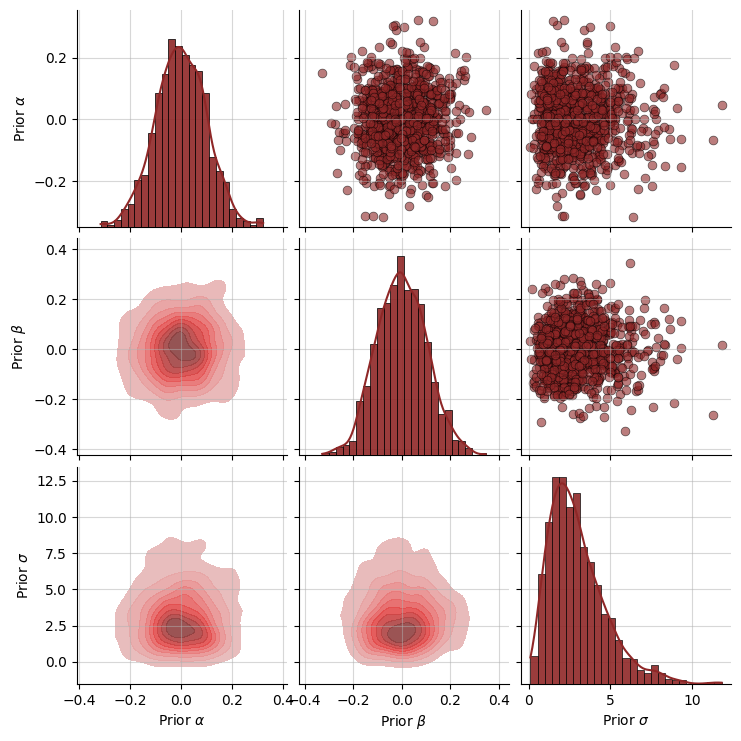

In [161]:
f = prior.plot_prior2d(n_samples=1000)

In [162]:
# Optionally, get the mean and standard deviation of the prior.
prior_mean, prior_stds = prior.estimate_means_and_stds()
prior_mean, prior_stds

(array([[0.00244366, 0.0002141 , 3.00763933]]),
 array([[0.10031321, 0.10134866, 1.70829838]]))

## Step 2: Simulator

In [163]:
# Define the number of observation
N_OBS = 100

In [164]:
def simulator_fun(theta, num_obs, rng=None, *args):
    """ 
    Simulator for the autoregressive model AR(1). 

    Parameters
    ----------
    theta       : np.array of size (3,)
        Parameters for the AR(1) model: intercept (alpha), slope (beta), and scale (sigma).
    num_obs     : int
        Number of generated data points.
    rng         : np.random
        Random number generator. If unspecified, default generator is used.

    Returns
    -------
    data        : np.array of size (num_obs, )
        Generated time-series data.
    """

    if rng is None:
        rng = np.random.default_rng()

    alpha, beta, scale = theta

    data = np.zeros(num_obs)
    
    for i in range(1, num_obs):
        data[i] = rng.normal(loc=alpha + beta * data[i-1], scale=scale)

    return data

In [305]:
prior = prior_fun()
simulator = simulator_fun(theta=prior, num_obs=N_OBS)
simulator

array([  0.        ,  -4.43345112,   9.33869326,  -5.08015158,
        -8.22342314,  -2.67841336,   4.92531908,  -1.91712242,
        -6.07213245,   6.98115424,  13.71330072,   2.2229545 ,
        -0.49575632,  -2.34860426,   4.31746779,   7.88398113,
        -0.54159783,   1.32346117,  -3.02092917,   1.2607437 ,
         1.45726195,   3.11764409,  -6.0338002 ,  12.80330933,
         2.97499413,   2.11436303,   1.81126073,  -2.42563097,
        -3.8787101 ,   0.17836038,  -0.93527096,  -2.60352466,
        -1.73690181,   7.98726869,   5.90000043,   0.6098014 ,
        10.45323388,  -2.92609814,  -2.05730508,   4.1745599 ,
        -9.93197921,  -6.34732241,   4.02810685,  -8.30338578,
        -6.03947832,   8.94600498,   4.0513842 ,  -1.3823098 ,
         2.88645926,   1.47919724,  -3.87149299,   6.57302377,
         1.13084452,   0.71191437,   3.92459311,  -4.18006995,
         0.15159966,   8.03588272,  -5.89362159,  -3.13743354,
         7.65403181,   3.76500514,   7.4082384 ,   1.11

## Step 3: Generative Model

In [165]:
ar1_model = bf.simulation.GenerativeModel(
    prior=prior_fun,
    simulator=partial(simulator_fun, num_obs=N_OBS),
    name="AR1",
    simulator_is_batched=False
)

INFO:root:Performing 2 pilot runs with the AR1 model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 3)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 100)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


#### Step 3a: Prior Predictive Check

<Axes: ylabel='Count'>

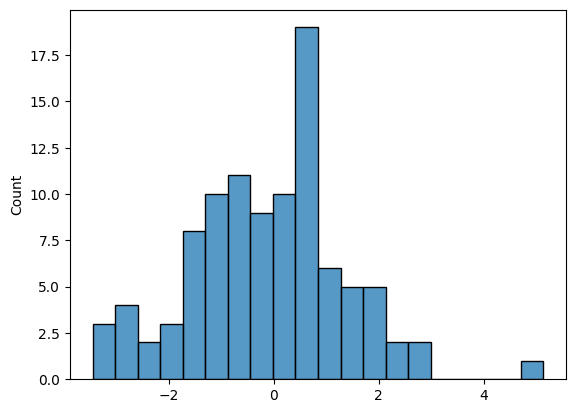

In [223]:
model_output = ar1_model(batch_size=5)
sns.histplot(model_output["sim_data"][0], bins=20)

In [297]:
summary_net = bf.summary_networks.SequenceNetwork()

In [298]:
inference_net = bf.inference_networks.InvertibleNetwork(num_params=len(prior.param_names), num_coupling_layers=4)

In [302]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net, name="ar1_amortizer")


SyntaxError: invalid syntax (2573354502.py, line 2)

In [300]:
trainer = bf.trainers.Trainer(
    amortizer=amortizer,
    generative_model=ar1_model
)

INFO:root:Performing a consistency check with provided components...


ConfigurationError: Could not carry out computations of generative_model ->configurator -> amortizer -> loss! Error trace:
 Exception encountered when calling layer 'multi_conv1d' (type MultiConv1D).

Input 0 of layer "conv1d" is incompatible with the layer: expected min_ndim=3, found ndim=2. Full shape received: (2, 100)

Call arguments received by layer 'multi_conv1d' (type MultiConv1D):
  • x=tf.Tensor(shape=(2, 100), dtype=float32)
  • kwargs={'training': 'None'}

## Step 4: Neural Approximator

We use ``TimeSeriesTransformer`` as our summary network.

In [248]:
# Would be interesting to do a model comparison between using SequenceNetwork and TimeSeriesTransformer as summary net.
summary_net = bf.summary_networks.TimeSeriesTransformer(input_dim=1)

In [284]:
# How do we know what the right coupling setting is?
inference_net = bf.inference_networks.InvertibleNetwork(num_params=len(prior.param_names), num_coupling_layers=4)

3

In [288]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net=inference_net, summary_net=summary_net, name="ar1_amortizer")

[]

## Step 5: Input Configurator

See Tutorial 6.6 for the rationale behind the input configurator.

In [279]:
# Should a specialized input configurator for time series be implemented?

def configurator(forward_dict):

    """
    Function to configure the simulated quantities (i.e., simulator outputs)
    into a neural network-friendly (BayesFlow) format.
    """
    # Prepare placeholder dict
    out_dict = {}

    # Get data from forward dict
    data = forward_dict["sim_data"].astype(np.float32)

    # Extract prior draws and z-standardize with previously computed means
    params = forward_dict["prior_draws"].astype(np.float32)
    # params = (params - prior_mean) / prior_stds

    # Remove a batch if it contains nan, inf or -inf
    idx_keep = np.all(np.isfinite(data), axis=(0, 1))
    if not np.all(idx_keep):
        print("Invalid value encountered...removing from batch")

    # Add to keys
    out_dict["summary_conditions"] = data[idx_keep].squeeze()
    out_dict["parameters"] = params[idx_keep]

    return out_dict

In [264]:
sim = ar1_model(1000)
sim['sim_data'].shape

(1000, 100)

In [280]:
out = configurator(sim)
out['summary_conditions']

array([[ 0.        , -4.021834  ,  4.0224633 , ..., -2.2316847 ,
        -1.4248583 ,  2.4372735 ],
       [ 0.        ,  0.07717021,  0.0472936 , ...,  0.18684547,
         0.09424023, -0.12252149],
       [ 0.        ,  0.6254038 ,  1.4216052 , ...,  0.8578479 ,
        -0.7668677 , -0.77074635],
       ...,
       [ 0.        , -0.9701969 ,  1.7928951 , ..., -2.9062283 ,
         0.05710469,  1.9977659 ],
       [ 0.        ,  1.7731278 ,  4.3805647 , ..., -1.3768244 ,
        -1.727093  , -3.4960942 ],
       [ 0.        , -0.5013288 , -0.59323233, ...,  2.1128354 ,
        -0.79104465, -2.9779794 ]], dtype=float32)

## Step 6: Training Phase

In [258]:
sim = ar1_model(16)
sim['sim_data'].shape

(16, 100)

In [292]:
trainer = bf.trainers.Trainer(
    generative_model=ar1_model,
    amortizer=amortizer,
    configurator=configurator,
    memory=True
)

INFO:root:Performing a consistency check with provided components...


ConfigurationError: Could not carry out computations of generative_model ->configurator -> amortizer -> loss! Error trace:
 Exception encountered when calling layer 'softmax' (type Softmax).

tuple index out of range

Call arguments received by layer 'softmax' (type Softmax):
  • inputs=tf.Tensor(shape=(2, 4), dtype=float32)
  • mask=None

In [35]:
amortizer.summary()

Model: "ar1_amortizer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network (Invert  multiple                  292936    
 ibleNetwork)                                                    
                                                                 
 time_series_transformer (T  multiple                  57878     
 imeSeriesTransformer)                                           
                                                                 
Total params: 350814 (1.34 MB)
Trainable params: 350790 (1.34 MB)
Non-trainable params: 24 (96.00 Byte)
_________________________________________________________________


In [294]:
history = trainer.train_online(epochs=1, iterations_per_epoch=100, batch_size=32)

Training epoch 1:   1%|          | 1/100 [00:27<44:40, 27.07s/it, Epoch: 1, Iter: 1,Loss: nan,W.Decay: nan,Avg.Loss: nan,Avg.W.Decay: nan,LR: 5.00E-04]

Invalid value encountered...removing from batch


Training epoch 1:   6%|▌         | 6/100 [00:46<06:58,  4.45s/it, Epoch: 1, Iter: 7,Loss: nan,W.Decay: nan,Avg.Loss: nan,Avg.W.Decay: nan,LR: 4.96E-04]

Invalid value encountered...removing from batch


Training epoch 1:  12%|█▏        | 12/100 [00:46<01:42,  1.16s/it, Epoch: 1, Iter: 13,Loss: nan,W.Decay: nan,Avg.Loss: nan,Avg.W.Decay: nan,LR: 4.82E-04]

...

Training epoch 1:  92%|█████████▏| 92/100 [00:52<00:00, 12.70it/s, Epoch: 1, Iter: 93,Loss: nan,W.Decay: nan,Avg.Loss: nan,Avg.W.Decay: nan,LR: 7.85E-06]

Invalid value encountered...removing from batch
Invalid value encountered...removing from batch


Training epoch 1:  98%|█████████▊| 98/100 [00:53<00:00, 13.30it/s, Epoch: 1, Iter: 99,Loss: nan,W.Decay: nan,Avg.Loss: nan,Avg.W.Decay: nan,LR: 4.93E-07]

Invalid value encountered...removing from batch


Training epoch 1: 100%|██████████| 100/100 [00:53<00:00,  1.88it/s, Epoch: 1, Iter: 100,Loss: nan,W.Decay: nan,Avg.Loss: nan,Avg.W.Decay: nan,LR: 1.23E-07]


In [296]:
fig = bf.diagnostics.plot_losses(history["train_losses"], history["val_losses"], moving_average=True)

KeyError: 'train_losses'